In [1]:
import numpy as np

def initialize_network(input_size, hidden_sizes, output_size):
    """
    Initialize weights and biases for a neural network.
    Args:
    input_size: Number of inputs to the network.
    hidden_sizes: List of neurons in each hidden layer (n, m, l...) size of layer n, size of layer m
    etc.
    output_size: Number of outputs of the network.
    Returns:
    List of (weights, biases) tuples for each layer.
    """
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    
    print('Layer sizes:', layer_sizes)
    
    network = []
    for i in range(len(layer_sizes) - 1):
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        #This creates a 2D array of random values with shape (layer_sizes[i + 1], layer_sizes[i]),
        #where each entry represents the weight connecting a neuron in the current layer to aneuron in the next layer.
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
    return network
#Código para inspeccionar la red
def inspect_network(network):
    for i, (weights, biases) in enumerate(network):
        print(f"\nLayer {i} → Layer {i+1}")
        print(f"Weights shape: {weights.shape}")
        print(f"Biases shape: {biases.shape}")
#Ejemplo del TP
input_size = 1
hidden_sizes = [2, 3]
output_size = 1

network = initialize_network(input_size, hidden_sizes, output_size)

inspect_network(network)
#Rdo: (2,1) → 2 neuronas, cada una recibe 1 input. (3,2) → 3 neuronas, cada una recibe 2 inputs. (1,3) → salida, recibe 3 inputs

Layer sizes: [1, 2, 3, 1]

Layer 0 → Layer 1
Weights shape: (2, 1)
Biases shape: (2,)

Layer 1 → Layer 2
Weights shape: (3, 2)
Biases shape: (3,)

Layer 2 → Layer 3
Weights shape: (1, 3)
Biases shape: (1,)


Layer sizes: [1, 2, 3, 1]


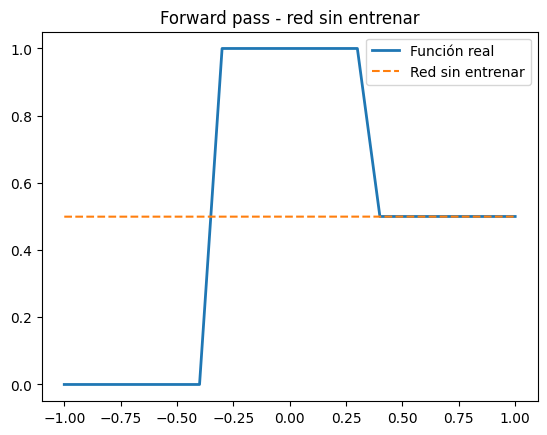

In [2]:
#Foward pass + graficar (Ejercicio 1.2.1)
#Definir la función del TP
def target_function(x):
    y = np.zeros_like(x)
    
    y[(x >= -0.33) & (x < 0.33)] = 1
    y[(x >= 0.33) & (x <= 1.0)] = 0.5
    
    return y
#Generar los datos (batch)
x = np.arange(-1, 1.01, 0.1)
y_true = target_function(x)

# reshape para que sea (batch_size, input_features)
x = x.reshape(-1, 1)
y_true = y_true.reshape(-1, 1)

#Foward pass
# Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_layer_batch(inputs, weights, biases):
    """
    Perform a forward pass for a layer with a batch of inputs.
    Args:
    inputs: Input to the layer (2D array: batch_size x input_features).
    weights: Weights of the layer (2D array: neurons x input_features).
    biases: Biases of the layer (1D array: neurons).
    Returns:
    Outputs of the layer (2D array: batch_size x neurons).
    """
    z = np.dot(inputs, weights.T) + biases # Weighted sum (broadcast biases)
    return sigmoid(z)

def forward_network_batch(inputs, network):
    """
    Perform a forward pass through the network for a batch of inputs.
    Args:
    inputs: Input to the network (2D array: batch_size x input_features).
    network: List of (weights, biases) for each layer.
    Returns:
    Activations for all layers.
    """
    activations = [inputs]
    
    for weights, biases in network:
        inputs = forward_layer_batch(inputs, weights, biases)
        activations.append(inputs)
        
    return activations
#Pruebo red aleatoria
network = initialize_network(1, [2, 3], 1)

activations = forward_network_batch(x, network)
y_pred = activations[-1]
#grafico
import matplotlib.pyplot as plt

plt.figure()

plt.plot(x, y_true, label="Función real", linewidth=2)
plt.plot(x, y_pred, label="Red sin entrenar", linestyle="--")

plt.legend()
plt.title("Forward pass - red sin entrenar")

plt.savefig("../results/forward_pass.png") 
plt.show()

¿cree que es posible solo por azar obtener una red que recupere la función? No, extremadamente imposible porque los pesos son aleatorios y la función es no lineal y discontinua

Layer sizes: [1, 2, 1]
Layer sizes: [1, 5, 5, 1]


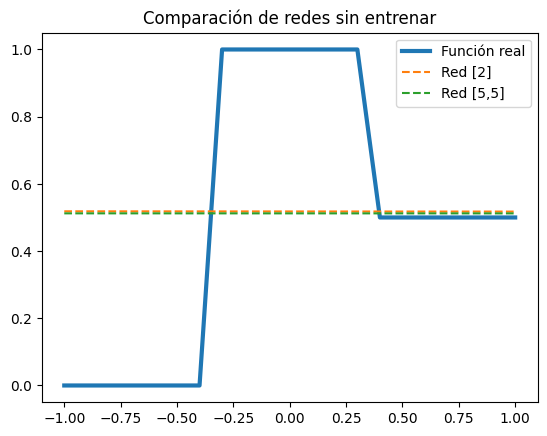

In [3]:
#Creo varias redes con distintas arquitecturas
network1 = initialize_network(1, [2], 1)
network2 = initialize_network(1, [5, 5], 1)
#Hago Foward para cada una
y_pred1 = forward_network_batch(x, network1)[-1]
y_pred2 = forward_network_batch(x, network2)[-1]
#grafico la comparacion de esas redes
import matplotlib.pyplot as plt

plt.figure()

plt.plot(x, y_true, label="Función real", linewidth=3)
plt.plot(x, y_pred1, label="Red [2]", linestyle="--")
plt.plot(x, y_pred2, label="Red [5,5]", linestyle="--")

plt.legend()
plt.title("Comparación de redes sin entrenar")

plt.savefig("../results/comparacion_redes.png")  
plt.show()

La figura muestra la comparación entre la función objetivo y las predicciones de 2 redes neuronales distintas con arquitecturas diferentes, todas sin entrenamiento previo (pesos inicializados aleatoriamente).
Observaciones: Ninguna de las 2 redes logra aproximar correctamente la función objetivo. Las predicciones presentan curvas suaves y continuas, mientras que la función real tiene discontinuidades (cambios bruscos). Diferentes arquitecturas producen salidas distintas, pero todas alejadas de la solución correcta.

Esto se debe a que los pesos y bias de la red fueron inicializados aleatoriamente, por lo que las transformaciones que realiza la red no están ajustadas al problema. La función sigmoide, además, introduce suavidad en la salida, lo que dificulta representar funciones tipo “escalón” sin un entrenamiento adecuado.

En conclusión, no es esperable que una red neuronal reproduzca la función objetivo únicamente por azar, independientemente de su arquitectura. Esto evidencia la necesidad de un proceso de entrenamiento que ajuste los parámetros de la red para minimizar el error.

Layer sizes: [1, 20, 1]
Epoch 0, Loss: 0.408962361892757
Epoch 500, Loss: 0.40227778241798046
Epoch 1000, Loss: 0.38598186271922996
Epoch 1500, Loss: 0.36559107333269675
Epoch 2000, Loss: 0.3598344781371473
Epoch 2500, Loss: 0.3592461331710403
Epoch 3000, Loss: 0.35898425189258154
Epoch 3500, Loss: 0.35863995776352725
Epoch 4000, Loss: 0.35823234588226593
Epoch 4500, Loss: 0.35777532551771724


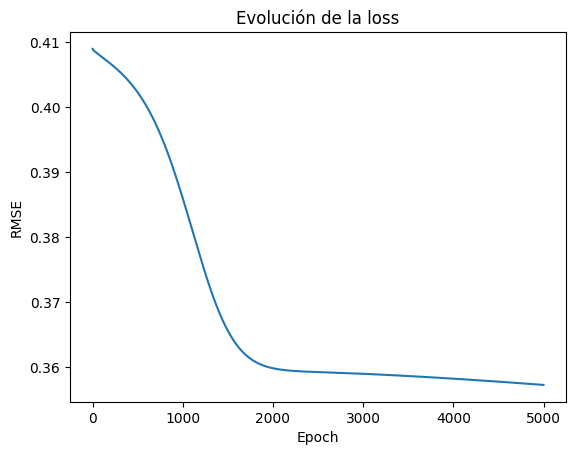

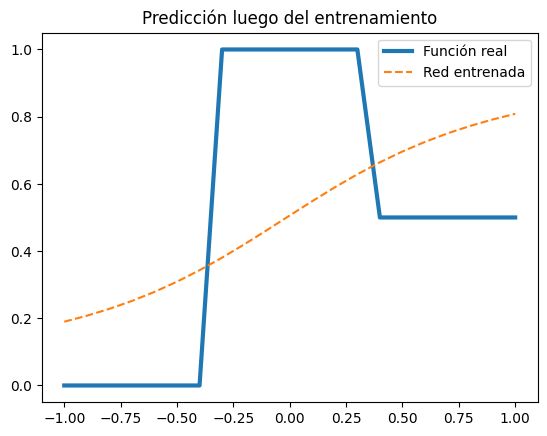

In [7]:
#Entrenamiento (Ejercicio 1.2.2). Objetivo: Entrenar la red, Ver cómo baja la loss, Comparar predicción final vs real
# Derivative of the sigmoid function
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
# Root Mean Squared Error (RMSE) loss function
def rmse_loss(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))
    
def backward_layer_batch(inputs, weights, biases, d_loss, activation_derivative):
    """Perform a backward pass for a layer with a batch of inputs.
    Args:
    inputs: Input to the layer (2D array: batch_size x input_features).
    weights: Weights of the layer (2D array: neurons x input_features).
    biases: Biases of the layer (1D array: neurons).
    d_loss: Gradients of the loss w.r.t. layer outputs (2D array: batch_size x neurons).
    activation_derivative: Derivative of the activation function (2D array: batch_size x neurons).
    Returns:
    d_weights: Gradients of the weights (2D array: neurons x input_features).
    d_biases: Gradients of the biases (1D array: neurons).
    d_inputs: Gradients of the inputs to propagate backward (2D array: batch_size x
    input_features).
    """
    # Gradients w.r.t. activations
    d_activation = d_loss * activation_derivative
    # Gradients w.r.t. weights and biases (average across batch)
    d_weights = np.dot(d_activation.T, inputs) / len(inputs)
    d_biases = np.mean(d_activation, axis=0)
    # Gradients to propagate backward to the previous layer
    d_inputs = np.dot(d_activation, weights)
    
    return d_weights, d_biases, d_inputs

def backward_network_batch(activations, network, y_true, learning_rate):
    """
    Perform a backward pass through the network for a batch of inputs.
    Args:
    activations: Activations from the forward pass.
    network: List of (weights, biases) for each layer.
    y_true: True output values (2D array: batch_size x output_neurons).
    learning_rate: Learning rate for updates.
    Returns:
    Loss for the batch.
    """
    y_pred = activations[-1]
    loss = np.mean(rmse_loss(y_pred, y_true))
    
    d_loss = (y_pred - y_true) / (len(y_true) * loss + 1e-15)
    # Backward pass through each layer
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        activation_derivative = sigmoid_derivative(activations[i + 1])
        # Compute gradients
        d_weights, d_biases, d_loss = backward_layer_batch(
            inputs, weights, biases, d_loss, activation_derivative
        )
        # Update weights and biases
        network[i] = (
            weights - learning_rate * d_weights,
            biases - learning_rate * d_biases
        )
        
    return loss

#Loop de entrenamiento
network = initialize_network(1, [20], 1)

epochs = 5000
learning_rate = 2.0

losses = []

for epoch in range(epochs):
    activations = forward_network_batch(x, network)
    loss = backward_network_batch(activations, network, y_true, learning_rate)
    
    losses.append(loss)
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")
#graficar la loss
plt.figure()
plt.plot(losses)

plt.title("Evolución de la loss")
plt.xlabel("Epoch")
plt.ylabel("RMSE")

plt.savefig("../results/loss.png")
plt.show()

#Comparar predicción final
y_pred_final = forward_network_batch(x, network)[-1]

plt.figure()

plt.plot(x, y_true, label="Función real", linewidth=3)
plt.plot(x, y_pred_final, label="Red entrenada", linestyle="--")

plt.legend()
plt.title("Predicción luego del entrenamiento")

plt.savefig("../results/prediccion_entrenada.png")
plt.show()

In [8]:
print(losses[0], losses[-1])

0.408962361892757 0.3572704441427504


Durante el entrenamiento se observa una disminución significativa de la función de pérdida, lo que indica que la red neuronal está logrando capturar parte de la estructura de la función objetivo.

A diferencia del caso inicial, donde la red convergía a una predicción constante, en este caso la salida presenta una forma sigmoidea, lo que evidencia que el modelo ha logrado aprender relaciones no lineales en los datos.

Sin embargo, la red no reproduce exactamente la forma escalonada de la función original, sino que genera transiciones suaves entre los distintos niveles. Esto se debe a la utilización de la función de activación sigmoide, que introduce continuidad en la salida de la red y limita su capacidad para modelar discontinuidades abruptas.

En consecuencia, el modelo logra una aproximación razonable de la función, aunque con errores en las zonas de transición


Entrenando con arquitectura = [1]

Entrenando con arquitectura = [2]

Entrenando con arquitectura = [5]

Entrenando con arquitectura = [10]

Entrenando con arquitectura = [2, 2]

Entrenando con arquitectura = [5, 5]

Entrenando con arquitectura = [10, 10]


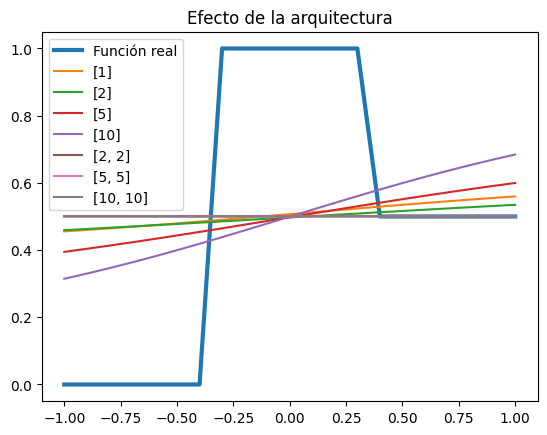

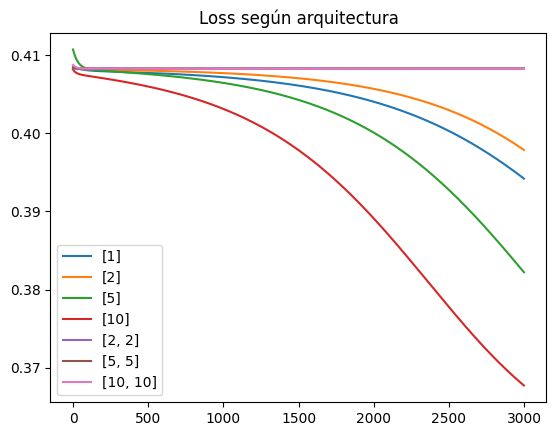

In [2]:
#Ejercicio 1.2.3 (A): efecto de epochs.
import numpy as np
import matplotlib.pyplot as plt

# FUNCIÓN OBJETIVO
def target_function(x):
    y = np.zeros_like(x)
    y[(x >= -0.33) & (x < 0.33)] = 1
    y[(x >= 0.33) & (x <= 1.0)] = 0.5
    return y

# DATOS
x = np.arange(-1, 1.01, 0.1)
y_true = target_function(x)

x = x.reshape(-1, 1)
y_true = y_true.reshape(-1, 1)

# RED NEURONAL
def initialize_network(input_size, hidden_sizes, output_size):
    layer_sizes = [input_size] + hidden_sizes + [output_size]
    
    network = []
    for i in range(len(layer_sizes) - 1):
        weights = np.random.randn(layer_sizes[i + 1], layer_sizes[i]) * 0.1
        biases = np.zeros(layer_sizes[i + 1])
        network.append((weights, biases))
    return network

# FORWARD
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward_layer_batch(inputs, weights, biases):
    z = np.dot(inputs, weights.T) + biases
    return sigmoid(z)

def forward_network_batch(inputs, network):
    activations = [inputs]
    for weights, biases in network:
        inputs = forward_layer_batch(inputs, weights, biases)
        activations.append(inputs)
    return activations

# BACKWARD
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def rmse_loss(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

def backward_layer_batch(inputs, weights, biases, d_loss, activation_derivative):
    d_activation = d_loss * activation_derivative
    
    d_weights = np.dot(d_activation.T, inputs) / len(inputs)
    d_biases = np.mean(d_activation, axis=0)
    
    d_inputs = np.dot(d_activation, weights)
    
    return d_weights, d_biases, d_inputs

def backward_network_batch(activations, network, y_true, learning_rate):
    y_pred = activations[-1]
    loss = np.mean(rmse_loss(y_pred, y_true))
    
    d_loss = (y_pred - y_true) / (len(y_true) * loss + 1e-15)
    
    for i in reversed(range(len(network))):
        weights, biases = network[i]
        inputs = activations[i]
        activation_derivative = sigmoid_derivative(activations[i + 1])
        
        d_weights, d_biases, d_loss = backward_layer_batch(
            inputs, weights, biases, d_loss, activation_derivative
        )
        
        network[i] = (
            weights - learning_rate * d_weights,
            biases - learning_rate * d_biases
        )
        
    return loss

# FUNCIÓN DE ENTRENAMIENTO
def train_network(network, x, y_true, epochs, learning_rate):
    losses = []
    
    for epoch in range(epochs):
        activations = forward_network_batch(x, network)
        loss = backward_network_batch(activations, network, y_true, learning_rate)
        losses.append(loss)
        
    return network, losses

# EXPERIMENTO A: EPOCHS
#epochs_list = [100, 500, 2000, 5000]
#learning_rate = 1.0

#for epochs in epochs_list:
#    print(f"Entrenando con {epochs} épocas...")
#    
#    network = initialize_network(1, [10], 1)  # arquitectura fija
#    
#    trained_net, losses = train_network(network, x, y_true, epochs, learning_rate)
#    
#    y_pred = forward_network_batch(x, trained_net)[-1]
#    
#    results[epochs] = {
#        "losses": losses,
#        "y_pred": y_pred
#    }

# GRÁFICO: PREDICCIONES
#plt.figure()
#plt.plot(x, y_true, label="Función real", linewidth=3)
#for epochs in epochs_list:
#    plt.plot(x, results[epochs]["y_pred"], label=f"{epochs} epochs")
#
#plt.legend()
#plt.title("Efecto del número de épocas")
#plt.savefig("../results/epochs_comparacion.png")
#plt.show()

# GRÁFICO: LOSS
#plt.figure()
#for epochs in epochs_list:
#    plt.plot(results[epochs]["losses"], label=f"{epochs} epochs")
#plt.legend()
#plt.title("Evolución de la loss")
#plt.savefig("../results/loss_epochs.png")
#plt.show()

# EXPERIMENTO B: LEARNING RATE
#learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]
#epochs = 3000  # fijo para comparar LR
#
#results_lr = {}
#
#for lr in learning_rates:
#    print(f"\nEntrenando con learning rate = {lr}")
#    
#    network = initialize_network(1, [10], 1)  # misma arquitectura
#    
#    trained_net, losses = train_network(network, x, y_true, epochs, lr)
#    
#    y_pred = forward_network_batch(x, trained_net)[-1]
#    
#    results_lr[lr] = {
#        "losses": losses,
#        "y_pred": y_pred
#    }
# GRÁFICO: PREDICCIONES
#plt.figure()
#
#plt.plot(x, y_true, label="Función real", linewidth=3)
#
#for lr in learning_rates:
#    plt.plot(x, results_lr[lr]["y_pred"], label=f"LR={lr}")
#
#plt.legend()
#plt.title("Efecto del learning rate")
#
#plt.savefig("../results/lr_comparacion.png")
#plt.show()
#
# GRÁFICO: LOSS
#plt.figure()
#
#for lr in learning_rates:
#    plt.plot(results_lr[lr]["losses"], label=f"LR={lr}")
#
#plt.legend()
#plt.title("Evolución de la loss (learning rate)")
#
#plt.savefig("../results/loss_lr.png")
#plt.show()
# EXPERIMENTO C: ARQUITECTURA DE LA RED
architectures = [
    [1],
    [2],
    [5],
    [10],
    [2, 2],
    [5, 5],
    [10, 10]
]

epochs = 3000
learning_rate = 1.0

results_arch = {}

for arch in architectures:
    print(f"\nEntrenando con arquitectura = {arch}")
    
    network = initialize_network(1, arch, 1)
    
    trained_net, losses = train_network(network, x, y_true, epochs, learning_rate)
    
    y_pred = forward_network_batch(x, trained_net)[-1]
    
    results_arch[str(arch)] = {
        "losses": losses,
        "y_pred": y_pred
    }
#GRAFICO DE PREDICCIONES
plt.figure()

plt.plot(x, y_true, label="Función real", linewidth=3)
for arch in architectures:
    plt.plot(x, results_arch[str(arch)]["y_pred"], label=f"{arch}")

plt.legend()
plt.title("Efecto de la arquitectura")
plt.savefig("../results/arquitectura_comparacion.png")
plt.show()
plt.figure()

for arch in architectures:
    plt.plot(results_arch[str(arch)]["losses"], label=f"{arch}")

plt.legend()
plt.title("Loss según arquitectura")

plt.savefig("../results/loss_arquitectura.png")
plt.show()


Interpretación de los resultados Ejercicio 1.2.3) Ajuste de hiperparàmetros 
A) Efecto del número de épocas en el entrenamiento de la red neuronal manteniendo fija la arquitectura y el learning rate. Ver gráfico epochs_comparacion.png en carpeta /results de la carpeta principal del TP. 
El gráfico muestra que: 
100–500 épocas → predicción casi constante (~0.5). La red no logra aprender la estructura de la función objetivo. 2000 épocas → leve pendiente. La red comienza a capturar parcialmente la relación entre entrada y salida. 
5000 épocas → curva más marcada (tipo S). La red logra aproximar mejor la función objetivo, generando una curva no lineal que se acerca a la forma esperada. Sin embargo, la aproximación aún es imperfecta, lo que sugiere que otros factores como el learning rate y la arquitectura también juegan un rol importante en el desempeño del modelo.
Entonces, pocas épocas → subentrenamiento (underfitting), muchas épocas → mejora progresiva, pero no alcanza solo con aumentar épocas para capturar bien la función.
B) Efecto del learning rate (LR) sobre el entrenamiento de la red neuronal, manteniendo fija la arquitectura y el número de épocas. Ver gráfico lr_comparacion.png en carpeta /results de la carpeta principal del TP. 
El gráfico muestra que: 
LR = 0.01 → línea casi plana. El aprendizaje es extremadamente lento. La red apenas modifica sus parámetros y la predicción se mantiene cercana a una línea constante, lo que indica una optimización ineficiente.
LR = 0.1 – 0.5 → mejora leve. La función de pérdida disminuye de manera sostenida y la red logra aproximar mejor la estructura de la función objetivo, evidenciando un aprendizaje estable.
LR = 1.0 → mejor aprendizaje. La red muestra una mayor capacidad de adaptación, generando curvas con forma sigmoidea más marcada.
LR = 2.0 → mejor aproximación (más curva). La red muestra una mayor capacidad de adaptación, generando curvas con forma sigmoidea más marcada, aunque en este caso, con posibles riesgos de inestabilidad.
C) Efecto de la arquitectura de la red neuronal manteniendo fijo el número de épocas y el learning rate. Ver gráfico arquitectura_comparacion.png en carpeta /results de la carpeta principal del TP. 
El gráfico muestra que:
[1], [2] → casi rectas. Las arquitecturas más simples producen predicciones cercanas a una línea recta, indicando una capacidad insuficiente para representar la función objetivo.
[5], [10] → más pendiente (mejoran algo). Al aumentar el número de neuronas en una sola capa, la red logra capturar parcialmente la relación entre entrada y salida, evidenciado por pendientes más pronunciadas, aunque aún sin reproducir completamente la función.
[5,5], [10,10] → no mejoran (incluso empeoran). Al utilizar arquitecturas más complejas, no se observa una mejora en la aproximación. Incluso ajustando hiperparámetros como el número de épocas y el learning rate, estas redes no logran superar a arquitecturas más simples.
En conclusión, aumentar la complejidad de la arquitectura no garantiza mejores resultados, y en ciertos casos puede dificultar el entrenamiento, especialmente en problemas simples y con conjuntos de datos pequeños.

El término overfitting (sobreajuste) se refiere a la situación en la que un modelo aprende en exceso los datos de entrenamiento, capturando no solo la estructura general sino también el ruido o particularidades específicas del conjunto de datos, lo que deteriora su capacidad de generalización.

En el contexto de este trabajo, no se observa un caso clásico de overfitting, ya que el modelo no llega a reproducir perfectamente la función objetivo. Sin embargo, al aumentar la complejidad de la arquitectura, se evidencia que redes más grandes no necesariamente mejoran el resultado.

Esto sugiere que un exceso de parámetros puede dificultar el proceso de optimización, especialmente cuando se dispone de pocos datos y se utilizan métodos de entrenamiento simples. En estos casos, en lugar de mejorar la aproximación, el modelo puede quedar atrapado en soluciones subóptimas.

Por lo tanto, existe un compromiso entre la complejidad del modelo y su capacidad de generalización: modelos demasiado simples no logran capturar la función (underfitting), mientras que modelos demasiado complejos pueden volverse difíciles de entrenar o propensos al sobreajuste en escenarios más generales.

El ajuste de hiperparámetros es fundamental en redes neuronales, ya que tanto el learning rate, el número de épocas como la arquitectura determinan no solo la capacidad del modelo, sino también la posibilidad de entrenarlo correctamente.